In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [4]:
df = pd.read_csv('/content/Dataset .csv')

In [5]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [7]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


LEVEL 1

Task **1**

Question 1. Most common cuisines

In [8]:
cuisine_counts = (df['Cuisines'].dropna().str.split(', ').explode().value_counts())

Top_cuisine = cuisine_counts.head(3).reset_index()
Top_cuisine.columns = ['Cuisine', 'Restaurant Counts']
Top_cuisine

,Cuisine,Restaurant Counts
0,North Indian,3960
1,Chinese,2735
2,Fast Food,1986


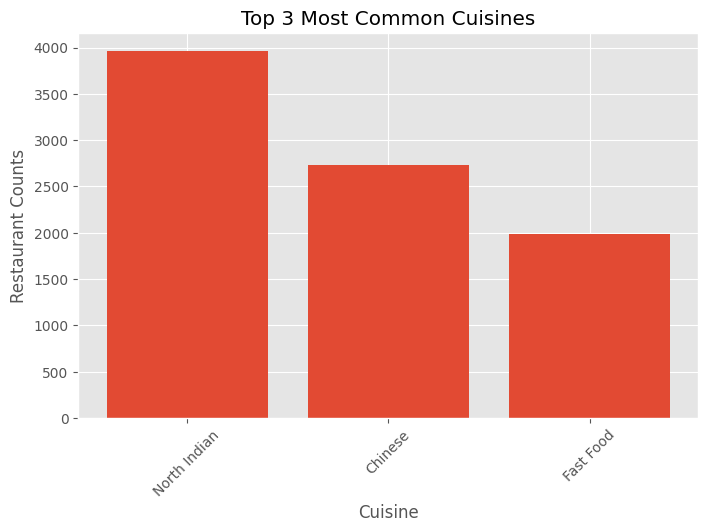

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(Top_cuisine['Cuisine'], Top_cuisine['Restaurant Counts'])
plt.xlabel('Cuisine')
plt.ylabel('Restaurant Counts')
plt.title('Top 3 Most Common Cuisines')
plt.xticks(rotation=45)
plt.show()


Question 2. percentage of restaurants that serve each of the top cuisines

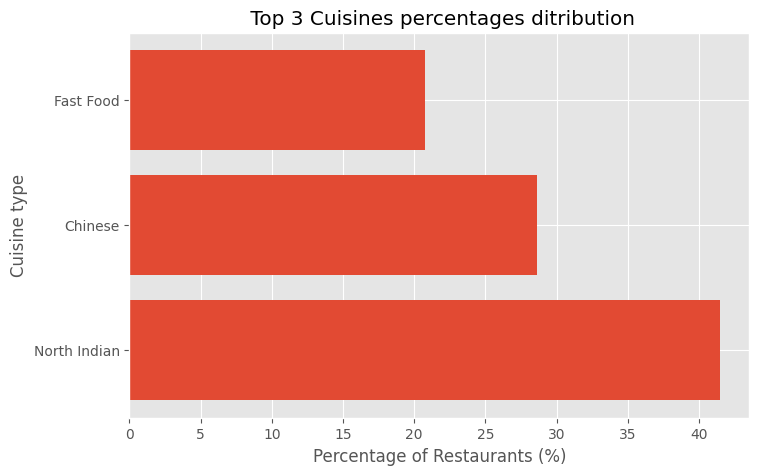

In [10]:
total_restaurants = len(df)
cuisine_percentages = (Top_cuisine['Restaurant Counts'] / total_restaurants * 100).round(2)
plt.figure(figsize=(8, 5))
plt.barh(Top_cuisine['Cuisine'], cuisine_percentages)
plt.xlabel('Percentage of Restaurants (%)')
plt.ylabel('Cuisine type')
plt.title(' Top 3 Cuisines percentages ditribution')
plt.show()

Task 2:

Question 1. City with heighest number of restarauent

In [11]:
city_counts = df['City'].value_counts()
top_city = city_counts.idxmax()
top_city_count= city_counts.max()
print(f"The city with the highest number of restaurants is {top_city} with {top_city_count} restaurants.")

The city with the highest number of restaurants is New Delhi with 5473 restaurants.


Question 2. average rating of restarauent in each city

In [12]:
avg_rating_city = df.groupby('City')['Aggregate rating'].mean().round(2)
avg_rating_city

,Aggregate rating
City,
Abu Dhabi,4.30
Agra,3.96
Ahmedabad,4.16
Albany,3.56
Allahabad,3.40
...,...
Weirton,3.90
Wellington City,4.25
Winchester Bay,3.20


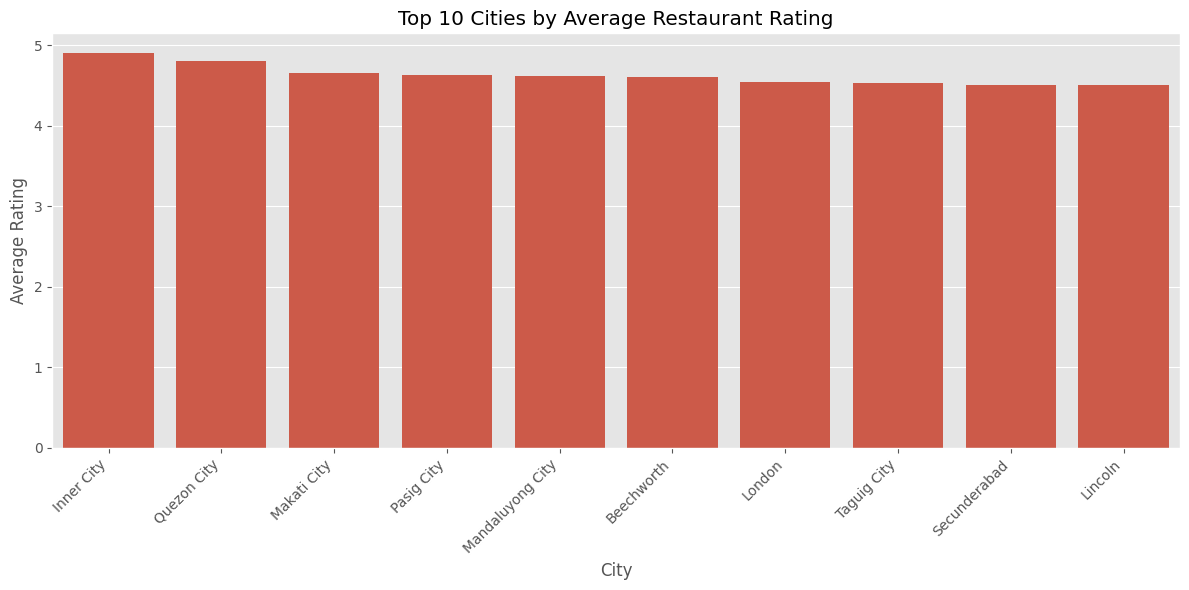

In [13]:
plt.figure(figsize=(12, 6))
top_10_cities = avg_rating_city.sort_values(ascending=False).head(10)
sns.barplot(x=top_10_cities.index, y=top_10_cities.values)
plt.xlabel('City')
plt.ylabel('Average Rating')
plt.title('Top 10 Cities by Average Restaurant Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() #
plt.show()

Question 3. city with highest average rating

In [14]:
top_city_rating = avg_rating_city.idxmax()
top_city_rating = avg_rating_city.max()
print(f"The city with the highest average rating is {top_city} with an average rating of {top_city_rating}.")

The city with the highest average rating is New Delhi with an average rating of 4.9.


Task 3 : Price Range Distribution

Question 1. a histogram or bar chart to
visualize the distribution of price ranges
among the restaurants

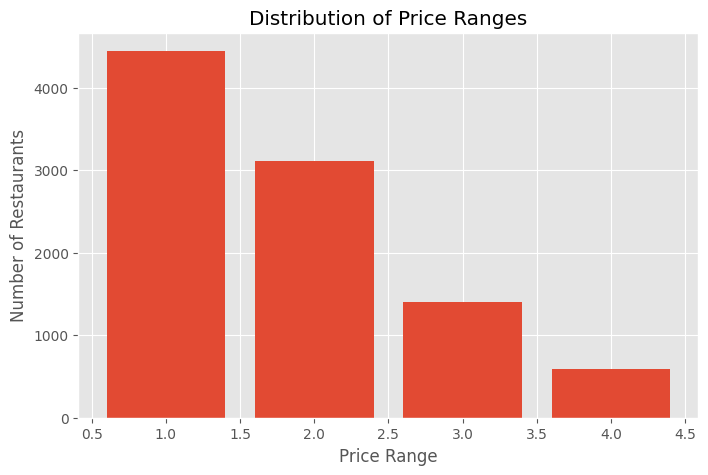

In [15]:
distribution_price = df['Price range'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(distribution_price.index, distribution_price.values)
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')
plt.title('Distribution of Price Ranges')
plt.show()

Question 2. The percentage of restaurants
in each price range category.

In [16]:
price_range_counts = df['Price range'].value_counts()
total_restaurants = len(df)
price_range_percentages = (price_range_counts / total_restaurants * 100).round(2)
print(price_range_percentages)

Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64


Task 4 : Deleviry PArtner

Question 1. Determine the percentage of restaurants
that offer online delivery

In [17]:
online_deleviry = df['Has Online delivery'].value_counts (normalize=True).round(2) * 100
print(online_deleviry)

Has Online delivery
No     74.0
Yes    26.0
Name: proportion, dtype: float64


Question 2. Compare the average ratings of restaurants
with online delivery.

In [18]:
average_rating =df[df['Has Online delivery'] == 'Yes']['Aggregate rating'].mean().round(2)
print(average_rating)

3.25


 average ratings of restaurants
 without online delivery.

In [19]:
average_rating_without_delivery = df[df['Has Online delivery'] == 'No']['Aggregate rating'].mean().round(2)
print(average_rating_without_delivery)

2.47
